_This Notebook extracts the Open Water raster pixels from the LGN dataset. Then it reprojects these raster pixels to the different CRS'es used in the thesis._

## Importing Functions

In [1]:
from functions.io_funcs import (
    batch_func,
)

from functions.raster_plot_funcs import (
    quick_rstr_plot_func,
)

from functions.raster_ops_funcs import (
    clip_with_rasterio_func,
    reproject_raster_func,
)

## Setting directory

In [ ]:
from paths.OG_paths import (
    #######################################
    #          GENERAL POLYGONS           #
    #######################################
    # |         Veluwe polygons           |
    # +===================================+ 
    veluwe_polygon__n2000__RD__gpkg_path,
    veluwe_polygon__ruim__RD__gpkg_path,


    #######################################
    #           LGN RAW Rasters           #
    #######################################
    lgn2018__nl__raw__RD__rstr_path,
    lgn2019__nl__raw__RD__rstr_path,
    lgn2020__nl__raw__RD__rstr_path,
    lgn2021__nl__raw__RD__rstr_path,
    lgn2022__nl__raw__RD__rstr_path,
    lgn2023__nl__raw__RD__rstr_path,
    lgn2024__nl__raw__RD__rstr_path,


    #######################################
    #            00_common_dfs            #
    #######################################
    # |        n03_LGN_legend_dfs         |
    # +===================================+ 
    lgn2018_reference__df_path,
    lgn2019_reference__df_path,
    lgn2020_reference__df_path,
    lgn2021_reference__df_path,
    lgn2022_reference__df_path,
    lgn2023_reference__df_path,
    lgn2024_reference__df_path,


    #######################################
    #     01_pre_processing_hab_kart      #
    #######################################
    # |    n03_extract_OW_from_LGN        |
    # +===================================+ 
    # ---  LGN Veluwe clip ruim Maps  --- #
    # DIR
    lgn__ruim__clip__rstr_dir,
    # RD
    lgn2018__ruim__clip__RD__rstr_path,
    lgn2019__ruim__clip__RD__rstr_path,
    lgn2020__ruim__clip__RD__rstr_path,
    lgn2021__ruim__clip__RD__rstr_path,
    lgn2022__ruim__clip__RD__rstr_path,
    lgn2023__ruim__clip__RD__rstr_path,
    lgn2024__ruim__clip__RD__rstr_path,
    # WGS84
    lgn2018__ruim__clip__WGS84__rstr_path,
    lgn2019__ruim__clip__WGS84__rstr_path,
    lgn2020__ruim__clip__WGS84__rstr_path,
    lgn2021__ruim__clip__WGS84__rstr_path,
    lgn2022__ruim__clip__WGS84__rstr_path,
    lgn2023__ruim__clip__WGS84__rstr_path,
    lgn2024__ruim__clip__WGS84__rstr_path,
    # UTM32631
    lgn2018__ruim__clip__UTM32631__rstr_path,
    lgn2019__ruim__clip__UTM32631__rstr_path,
    lgn2020__ruim__clip__UTM32631__rstr_path,
    lgn2021__ruim__clip__UTM32631__rstr_path,
    lgn2022__ruim__clip__UTM32631__rstr_path,
    lgn2023__ruim__clip__UTM32631__rstr_path,
    lgn2024__ruim__clip__UTM32631__rstr_path,

    # --- LGN Veluwe clip N2000 Maps --- #
    # DIR
    lgn__n2000__clip__rstr_dir,
    # RD
    lgn2018__n2000__clip__RD__rstr_path,
    lgn2019__n2000__clip__RD__rstr_path,
    lgn2020__n2000__clip__RD__rstr_path,
    lgn2021__n2000__clip__RD__rstr_path,
    lgn2022__n2000__clip__RD__rstr_path,
    lgn2023__n2000__clip__RD__rstr_path,
    lgn2024__n2000__clip__RD__rstr_path,
    # WGS84
    lgn2018__n2000__clip__WGS84__rstr_path,
    lgn2019__n2000__clip__WGS84__rstr_path,
    lgn2020__n2000__clip__WGS84__rstr_path,
    lgn2021__n2000__clip__WGS84__rstr_path,
    lgn2022__n2000__clip__WGS84__rstr_path,
    lgn2023__n2000__clip__WGS84__rstr_path,
    lgn2024__n2000__clip__WGS84__rstr_path,
    
    # --- LGN_OW n2000 clip rstr --- #
    # DIR
    lgn_plusOW__n2000__clip__rstr_dir,
    # RD
    lgn2018_plusOW__n2000__clip__RD__rstr_path,
    lgn2019_plusOW__n2000__clip__RD__rstr_path,
    lgn2020_plusOW__n2000__clip__RD__rstr_path,
    lgn2021_plusOW__n2000__clip__RD__rstr_path,
    lgn2022_plusOW__n2000__clip__RD__rstr_path,
    lgn2023_plusOW__n2000__clip__RD__rstr_path,
    lgn2024_plusOW__n2000__clip__RD__rstr_path,
    # WGS84
    lgn2018_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2019_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2020_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2021_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2022_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2023_plusOW__n2000__clip__WGS84__rstr_path,
    lgn2024_plusOW__n2000__clip__WGS84__rstr_path,
)

## Importing packages

In [3]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Importing files

In [4]:
# years definition
years_2018_2024 = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [5]:
# LGN classes dfs
lgn__reference__df_template = """
lgn{year}_reference__df = pd.read_pickle(lgn{year}_reference__df_path)
"""

batch_func(years_2018_2024, lgn__reference__df_template, globals())

## Clipping to Ruime Veluwe Extent

In [6]:
lgn__ruim__clip__RD__rstr_template = """
lgn{year}__ruim__clip__RD__rstr_path, lgn{year}__ruim__clip__RD__rstr_epsg, lgn{year}__ruim__clip__RD__rstr_status = clip_with_rasterio_func(
    raster_path=lgn{year}__nl__raw__RD__rstr_path,
    gpkg_path=veluwe_polygon__ruim__RD__gpkg_path,
    out_dir=lgn__ruim__clip__rstr_dir,
    out_filename="lgn{year}__ruim__clip__RD__rstr.tif",
    overwrite=True
)
"""

In [7]:
batch_func(years_2018_2024, lgn__ruim__clip__RD__rstr_template, globals())

Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2018__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2019__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2020__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2021__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2022__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2023__ruim__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__cli

## Clipping to N2000 Veluwe Extent

In [8]:
# Clipping the LGN rasters to the Veluwe polygon
lgn__n2000__clip__RD__rstr_template = """
lgn{year}__n2000__clip__RD__rstr_path, lgn{year}__n2000__clip__RD__rstr_epsg, lgn{year}__n2000__clip__RD__rstr_status = clip_with_rasterio_func(
    raster_path=lgn{year}__nl__raw__RD__rstr_path,
    gpkg_path=veluwe_polygon__n2000__RD__gpkg_path,
    out_dir=lgn__n2000__clip__rstr_dir,
    out_filename="lgn{year}__n2000__clip__RD__rstr.tif",
    overwrite=True
)
"""

In [9]:
batch_func(years_2018_2024, lgn__n2000__clip__RD__rstr_template, globals())

Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2018__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2019__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2020__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2021__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2022__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2023__n2000__clip__RD__rstr.tif
Clipped raster (EPSG:28992) written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lg

## First visualization

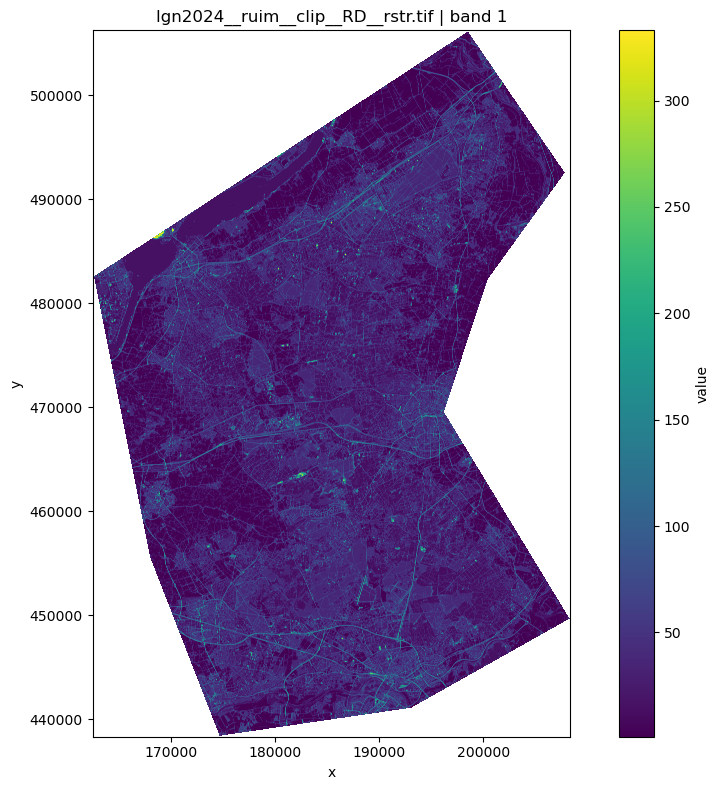

In [10]:
quick_rstr_plot_func(lgn2024__ruim__clip__RD__rstr_path)

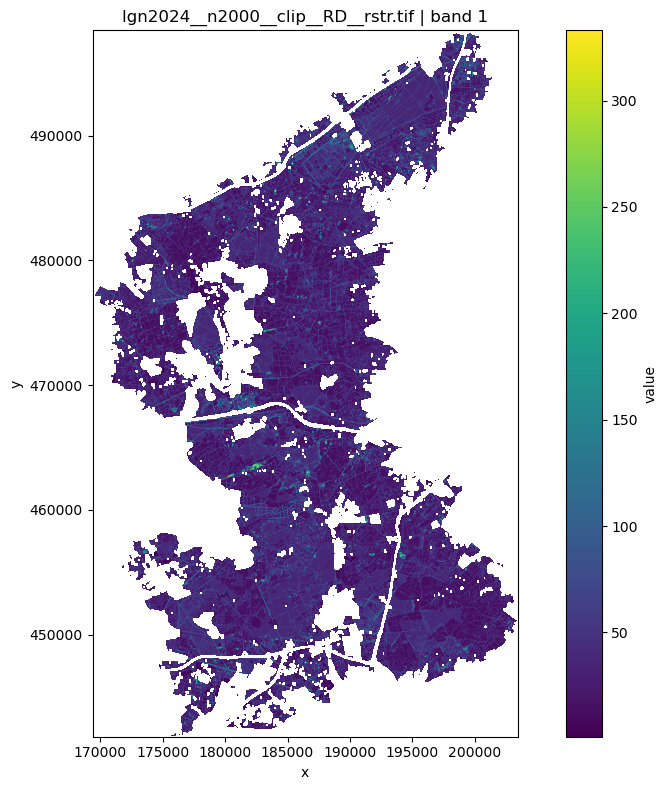

In [11]:
quick_rstr_plot_func(lgn2024__n2000__clip__RD__rstr_path)

## Selecting Open Water in N2000 area

In [12]:
# Selecting only class 16 as this is defined as 'zoet water' in all LGN versions
lgn_plusOW__n2000__clip__RD__rstr_template = """
lgn{year}_plusOW__n2000__clip__RD__rstr_path = lgn{year}_plusOW__n2000__clip__RD__rstr_path

with rasterio.open(lgn{year}__n2000__clip__RD__rstr_path) as src:
    a = src.read(1)
    nodata = src.nodata

    mask16 = (a == 16)
    if nodata is not None:
        mask16 &= (a != nodata)

    mask16_u8 = mask16.astype("uint8")

    profile = src.profile.copy()
    profile.update(dtype="uint8", count=1, nodata=0)

    with rasterio.open(lgn{year}_plusOW__n2000__clip__RD__rstr_path, "w", **profile) as dst:
        dst.write(mask16_u8, 1)

print("lgn {year}:", lgn{year}_plusOW__n2000__clip__RD__rstr_path, "| pixels==16:", int(mask16.sum()))
"""

In [13]:
batch_func(years_2018_2024, lgn_plusOW__n2000__clip__RD__rstr_template, globals())

lgn 2018: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2018_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 47367
lgn 2019: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2019_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 47500
lgn 2020: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2020_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 48358
lgn 2021: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2021_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 72957
lgn 2022: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2022_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 106491
lgn 2023: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2023_plusOW__n2000__clip__RD__rstr.tif | pixels==16: 115163
lgn 2024: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_pl

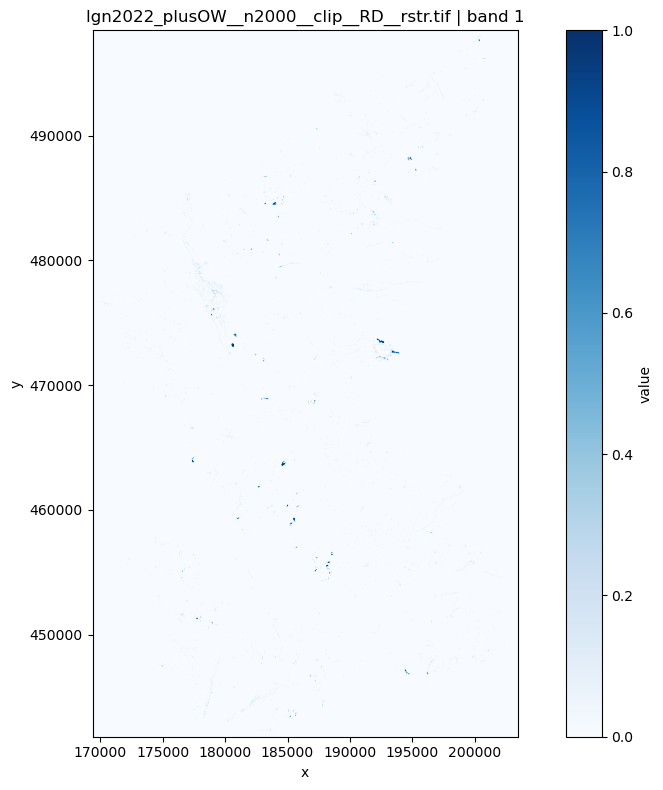

In [14]:
quick_rstr_plot_func(lgn2022_plusOW__n2000__clip__RD__rstr_path, mask_band=None, cmap='Blues')

## Reprojecting from RD to WSG84

In [18]:
# Ruime Veluwe clip
lgn__ruim__clip__WGS84__rstr_template = """
lgn{year}__ruim__clip__WGS84__rstr_path = reproject_raster_func(
    in_raster_path=lgn{year}__ruim__clip__RD__rstr_path,
    dst_crs="EPSG:4326",
    output_dir=lgn__ruim__clip__rstr_dir,
    output_filename="lgn{year}__ruim__clip__WGS84__rstr.tif",
    overwrite=True,
    resampling="nearest",
    check_output_crs=True
)

print("lgn {year} reprojected raster written to:", lgn{year}__ruim__clip__WGS84__rstr_path)
"""

In [19]:
batch_func(years_2018_2024, lgn__ruim__clip__WGS84__rstr_template, globals())

lgn 2018 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2018__ruim__clip__WGS84__rstr.tif
lgn 2019 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2019__ruim__clip__WGS84__rstr.tif
lgn 2020 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2020__ruim__clip__WGS84__rstr.tif
lgn 2021 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2021__ruim__clip__WGS84__rstr.tif
lgn 2022 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2022__ruim__clip__WGS84__rstr.tif
lgn 2023 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2023__ruim__clip__WGS84__rstr.tif
lgn 2024 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\

In [20]:
# N2000 Veluwe clip
lgn__n2000__clip__WGS84__rstr_template = """
lgn{year}__n2000__clip__WGS84__rstr_path = reproject_raster_func(
    in_raster_path=lgn{year}__n2000__clip__RD__rstr_path,
    dst_crs="EPSG:4326",
    output_dir=lgn__n2000__clip__rstr_dir,
    output_filename="lgn{year}__n2000__clip__WGS84__rstr.tif",
    overwrite=True,
    resampling="nearest",
    check_output_crs=True
)

print("lgn {year} reprojected raster written to:", lgn{year}__n2000__clip__WGS84__rstr_path)
"""

In [21]:
batch_func(years_2018_2024, lgn__n2000__clip__WGS84__rstr_template, globals())

lgn 2018 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2018__n2000__clip__WGS84__rstr.tif
lgn 2019 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2019__n2000__clip__WGS84__rstr.tif
lgn 2020 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2020__n2000__clip__WGS84__rstr.tif
lgn 2021 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2021__n2000__clip__WGS84__rstr.tif
lgn 2022 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2022__n2000__clip__WGS84__rstr.tif
lgn 2023 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__n2000__clip__rstrs\lgn2023__n2000__clip__WGS84__rstr.tif
lgn 2024 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismap

In [22]:
# N2000 plusOW
lgn_plusOW__n2000__clip__WGS84__rstr_template = """
lgn{year}_plusOW__n2000__clip__WGS84__rstr_path = reproject_raster_func(
    in_raster_path=lgn{year}_plusOW__n2000__clip__RD__rstr_path,
    dst_crs="EPSG:4326",
    output_dir=lgn_plusOW__n2000__clip__rstr_dir,
    output_filename="lgn{year}_plusOW__n2000__clip__WGS84__rstr.tif",
    overwrite=True,
    resampling="nearest",
    check_output_crs=True
)

print("lgn {year} plusOW reprojected raster written to:", lgn{year}_plusOW__n2000__clip__WGS84__rstr_path)
"""

In [23]:
batch_func(years_2018_2024, lgn_plusOW__n2000__clip__WGS84__rstr_template, globals())

lgn 2018 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2018_plusOW__n2000__clip__WGS84__rstr.tif
lgn 2019 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2019_plusOW__n2000__clip__WGS84__rstr.tif
lgn 2020 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2020_plusOW__n2000__clip__WGS84__rstr.tif
lgn 2021 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2021_plusOW__n2000__clip__WGS84__rstr.tif
lgn 2022 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__rstrs\lgn2022_plusOW__n2000__clip__WGS84__rstr.tif
lgn 2023 plusOW reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn_plusOW__n2000__clip__r

## Reprojection to UTM32631

In [24]:
# Ruime Veluwe clip
lgn__ruim__clip__UTM32631__rstr_template = """
lgn{year}__ruim__clip__UTM32631__rstr_path = reproject_raster_func(
    in_raster_path=lgn{year}__ruim__clip__RD__rstr_path,
    dst_crs="EPSG:32631",
    output_dir=lgn__ruim__clip__rstr_dir,
    output_filename="lgn{year}__ruim__clip__UTM32631__rstr.tif",
    overwrite=True,
    resampling="nearest",
    check_output_crs=True
)

print("lgn {year} reprojected raster written to:", lgn{year}__ruim__clip__UTM32631__rstr_path)
"""

In [25]:
batch_func(years_2018_2024, lgn__ruim__clip__UTM32631__rstr_template, globals())

lgn 2018 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2018__ruim__clip__UTM32631__rstr.tif
lgn 2019 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2019__ruim__clip__UTM32631__rstr.tif
lgn 2020 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2020__ruim__clip__UTM32631__rstr.tif
lgn 2021 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2021__ruim__clip__UTM32631__rstr.tif
lgn 2022 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2022__ruim__clip__UTM32631__rstr.tif
lgn 2023 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_basismaps_processed\lgn\lgn__ruim__clip__rstrs\lgn2023__ruim__clip__UTM32631__rstr.tif
lgn 2024 reprojected raster written to: D:\Thesis\10.Thesis_Data\01_ba

End of the Notebook